In [8]:
from collections import deque

class Packet:
    def __init__(self, pid, arrival, inp, out):
        self.id = pid
        self.arrival = arrival
        self.input = inp
        self.output = out

packets = [
    Packet("p1",0,0,0), Packet("p2",0,0,1), Packet("p3",0,1,0),
    Packet("p4",0,1,2), Packet("p5",0,2,0),
    Packet("p6",1,0,2), Packet("p7",1,2,1),
    Packet("p8",2,1,1), Packet("p9",2,2,2),
    Packet("p10",3,0,1), Packet("p11",3,1,0), Packet("p12",3,2,1),
    Packet("p13",4,0,0), Packet("p14",4,1,2), Packet("p15",4,2,2),
    Packet("p16",5,0,2), Packet("p17",5,1,1), Packet("p18",5,2,0)
]

input_queues = [deque() for _ in range(3)]

t = 0
delivered = 0
total_packets = len(packets)

while delivered < total_packets:
    print(f"\n========== Time Slot {t} ==========")

    # Add arrivals
    for p in packets:
        if p.arrival == t:
            input_queues[p.input].append(p)

    # Print queues
    print("Queues:")
    for i in range(3):
        q = [f"{p.id}(O{p.output})" for p in input_queues[i]]
        print(f"  I{i}: {q}")

    output_busy = [False]*3
    input_sent = [False]*3

    # Transmission
    print("\nTransmissions:")
    for i in range(3):
        if input_queues[i]:
            p = input_queues[i][0]

            if not output_busy[p.output]:
                print(f"  {p.id}: I{i} → O{p.output}")
                output_busy[p.output] = True
                input_sent[i] = True
                input_queues[i].popleft()
                delivered += 1

    # HoL Blocking Detection
    print("\nHoL Blocking:")
    hol_found = False

    for i in range(3):
        if input_queues[i] and not input_sent[i]:
            queue = list(input_queues[i])
            front = queue[0]

            if output_busy[front.output] and len(queue) > 1:
                for p in queue[1:]:
                    if not output_busy[p.output]:
                        print(f"  At I{i}: {front.id} blocks {p.id}")
                        hol_found = True
                        break

    if not hol_found:
        print("  None")

    t += 1

print("\nTotal Service Time =", t)


========== Time Slot 0 ==========
Queues:
  I0: ['p1(O0)', 'p2(O1)']
  I1: ['p3(O0)', 'p4(O2)']
  I2: ['p5(O0)']

Transmissions:
  p1: I0 → O0

HoL Blocking:
  At I1: p3 blocks p4

========== Time Slot 1 ==========
Queues:
  I0: ['p2(O1)', 'p6(O2)']
  I1: ['p3(O0)', 'p4(O2)']
  I2: ['p5(O0)', 'p7(O1)']

Transmissions:
  p2: I0 → O1
  p3: I1 → O0

HoL Blocking:
  None

========== Time Slot 2 ==========
Queues:
  I0: ['p6(O2)']
  I1: ['p4(O2)', 'p8(O1)']
  I2: ['p5(O0)', 'p7(O1)', 'p9(O2)']

Transmissions:
  p6: I0 → O2
  p5: I2 → O0

HoL Blocking:
  At I1: p4 blocks p8

========== Time Slot 3 ==========
Queues:
  I0: ['p10(O1)']
  I1: ['p4(O2)', 'p8(O1)', 'p11(O0)']
  I2: ['p7(O1)', 'p9(O2)', 'p12(O1)']

Transmissions:
  p10: I0 → O1
  p4: I1 → O2

HoL Blocking:
  None

========== Time Slot 4 ==========
Queues:
  I0: ['p13(O0)']
  I1: ['p8(O1)', 'p11(O0)', 'p14(O2)']
  I2: ['p7(O1)', 'p9(O2)', 'p12(O1)', 'p15(O2)']

Transmissions:
  p13: I0 → O0
  p8: I1 → O1

HoL Blocking:
  At I2: p7

In [15]:
"""
Part 2: Virtual Output Queue (VOQ) - Optimal Exhaustive Search
3x3 crossbar switch simulation using VOQ architecture.

Strategy:
  1. First run a greedy pass to get an upper bound.
  2. DFS exhaustive search pruned by:
       - current_t >= best_time
       - lower bound: t + ceil(remaining/3) >= best_time
  3. Only try MAXIMAL matchings (maximises throughput).
  4. Memoize visited (voq_state, t) states.
"""

from collections import defaultdict

NUM_PORTS = 3

PACKETS = [
    ("p1",  0, 0, 0), ("p2",  0, 0, 1), ("p3",  0, 1, 0),
    ("p4",  0, 1, 2), ("p5",  0, 2, 0), ("p6",  1, 0, 2),
    ("p7",  1, 2, 1), ("p8",  2, 1, 1), ("p9",  2, 2, 2),
    ("p10", 3, 0, 1), ("p11", 3, 1, 0), ("p12", 3, 2, 1),
    ("p13", 4, 0, 0), ("p14", 4, 1, 2), ("p15", 4, 2, 2),
    ("p16", 5, 0, 2), ("p17", 5, 1, 1), ("p18", 5, 2, 0),
]

by_time = defaultdict(list)
for pid, arr, src, dst in PACKETS:
    by_time[arr].append((pid, arr, src, dst))

MAX_ARRIVAL = max(arr for _, arr, _, _ in PACKETS)


def enqueue(voq, t):
    nv = [[list(q) for q in row] for row in voq]
    for pid, arr, src, dst in by_time.get(t, []):
        nv[src][dst].append(pid)
    return nv


def total_packets(voq):
    return sum(len(voq[i][o]) for i in range(NUM_PORTS) for o in range(NUM_PORTS))


def get_maximal_matchings(voq):
    feasible = [(i, o) for i in range(NUM_PORTS)
                for o in range(NUM_PORTS) if voq[i][o]]
    if not feasible:
        return [{}]
    maximal = []

    def bt(k, used_in, used_out, cur):
        can_extend = any(i not in used_in and o not in used_out
                         for i, o in feasible[k:])
        if not can_extend:
            maximal.append(dict(cur))
            return
        for idx in range(k, len(feasible)):
            i, o = feasible[idx]
            if i not in used_in and o not in used_out:
                used_in.add(i); used_out.add(o); cur[i] = o
                bt(idx + 1, used_in, used_out, cur)
                used_in.remove(i); used_out.remove(o); del cur[i]

    bt(0, set(), set(), {})
    return maximal if maximal else [{}]


def apply_matching(voq, matching):
    nv = [[list(q) for q in row] for row in voq]
    sent = []
    for i, o in matching.items():
        pkt = nv[i][o].pop(0)
        sent.append((pkt, i, o))
    return nv, sent


def voq_size_vector(voq):
    """Use queue *lengths* for memo key (order within queue doesn't affect optimality bound)."""
    return tuple(len(voq[i][o]) for i in range(NUM_PORTS) for o in range(NUM_PORTS))


best = [999, []]
visited = {}   # (size_vector, t) -> best_time achieved from this state


def search(voq, t, log):
    if t >= best[0]:
        return
    voq = enqueue(voq, t)
    rem = total_packets(voq)
    if rem == 0:
        if t < best[0]:
            best[0] = t
            best[1] = list(log)
        return
    lb = (rem + NUM_PORTS - 1) // NUM_PORTS
    if t + lb >= best[0]:
        return

    # Memoization: if we've visited this (state, t) and already achieved a
    # better or equal finish time, skip.
    key = (voq_size_vector(voq), t)
    if key in visited and visited[key] <= best[0]:
        return
    visited[key] = best[0]

    for matching in get_maximal_matchings(voq):
        nv, sent = apply_matching(voq, matching)
        log.append((t, matching, sent))
        search(nv, t + 1, log)
        log.pop()


def greedy_ub():
    voq = [[[] for _ in range(NUM_PORTS)] for _ in range(NUM_PORTS)]
    t = 0
    log = []
    while True:
        voq = enqueue(voq, t)
        if total_packets(voq) == 0 and t > MAX_ARRIVAL:
            return t, log
        ms = get_maximal_matchings(voq)
        m = max(ms, key=len)
        nv, sent = apply_matching(voq, m)
        log.append((t, m, sent))
        voq = nv
        t += 1
        if t > 60:
            return t, log


def run_part2():
    print("=" * 60)
    print("PART 2: VOQ — Exhaustive Optimal Search")
    print("=" * 60)

    ub, ub_log = greedy_ub()
    print(f"Greedy upper bound: {ub} slots\n")
    best[0] = ub
    best[1] = ub_log

    voq0 = [[[] for _ in range(NUM_PORTS)] for _ in range(NUM_PORTS)]
    search(voq0, 0, [])

    best_time, best_log = best
    print(f"Optimal Total Service Time: t = {best_time}\n")
    print("Optimal Sequence of Matchings:")
    print("-" * 60)
    for t, matching, sent in best_log:
        pairs = ", ".join(f"I{i}→O{o}" for i, o in sorted(matching.items()))
        print(f"t = {t}:  Matching: [{pairs}]")
        for pid, inp, out in sent:
            print(f"    Sent {pid}  (I{inp} → O{out})")
    print("-" * 60)
    print(f"\nSwitch empties at the start of t = {best_time}  ({best_time} time slots used)")

    # Backlog

    voq = [[[] for _ in range(NUM_PORTS)] for _ in range(NUM_PORTS)]
    log_idx = 0

    for t in range(best_time + 1):
        voq = enqueue(voq, t)
        rem = total_packets(voq)

        if rem == 0:
            break
        matching = {}
        if log_idx < len(best_log) and best_log[log_idx][0] == t:
            matching = best_log[log_idx][1]
            log_idx += 1
        voq, _ = apply_matching(voq, matching)


if __name__ == "__main__":
    run_part2()

PART 2: VOQ — Exhaustive Optimal Search
Greedy upper bound: 7 slots

Optimal Total Service Time: t = 7

Optimal Sequence of Matchings:
------------------------------------------------------------
t = 0:  Matching: [I0→O1, I1→O2, I2→O0]
    Sent p2  (I0 → O1)
    Sent p4  (I1 → O2)
    Sent p5  (I2 → O0)
t = 1:  Matching: [I0→O2, I1→O0, I2→O1]
    Sent p6  (I0 → O2)
    Sent p3  (I1 → O0)
    Sent p7  (I2 → O1)
t = 2:  Matching: [I0→O0, I1→O1, I2→O2]
    Sent p1  (I0 → O0)
    Sent p8  (I1 → O1)
    Sent p9  (I2 → O2)
t = 3:  Matching: [I0→O1, I1→O0]
    Sent p10  (I0 → O1)
    Sent p11  (I1 → O0)
t = 4:  Matching: [I0→O0, I1→O2, I2→O1]
    Sent p13  (I0 → O0)
    Sent p14  (I1 → O2)
    Sent p12  (I2 → O1)
t = 5:  Matching: [I0→O2, I1→O1, I2→O0]
    Sent p16  (I0 → O2)
    Sent p17  (I1 → O1)
    Sent p18  (I2 → O0)
t = 6:  Matching: [I2→O2]
    Sent p15  (I2 → O2)
------------------------------------------------------------

Switch empties at the start of t = 7  (7 time slots used)


In [6]:
"""
Part 3: iSLIP Scheduling Algorithm for a 3x3 Crossbar Switch

The expected output shows up to 3 simultaneous sends per slot, which iSLIP
achieves through multiple iterations per time slot. This implementation runs
iSLIP with multiple iterations until no new matches are found, matching the
assignment's expected output exactly.
"""

from collections import deque

NUM_PORTS = 3

packets = [
    ("pp1",  0, 0), ("pp2",  0, 1), ("pp3",  1, 0), ("pp4",  1, 2),
    ("pp5",  2, 0), ("pp6",  0, 2), ("pp7",  2, 1), ("pp8",  1, 1),
    ("pp9",  2, 2), ("pp10", 0, 1), ("pp11", 1, 0), ("pp12", 2, 1),
    ("pp13", 0, 0), ("pp14", 1, 2), ("pp15", 2, 2), ("pp16", 0, 2),
    ("pp17", 1, 1), ("pp18", 2, 0),
]

arrivals = {
    0: [0, 1, 2, 3, 4],
    1: [5, 6],
    2: [7, 8],
    3: [9, 10, 11],
    4: [12, 13, 14],
    5: [15, 16, 17],
}

def islip_match(VOQ, grant_ptr, accept_ptr):
    """
    Run iSLIP matching (multiple iterations) until full matching found.
    Returns list of (input, output) pairs matched this time slot.
    Updates grant_ptr and accept_ptr in-place.
    """
    matched_in  = [False] * NUM_PORTS
    matched_out = [False] * NUM_PORTS
    result = []

    for _ in range(NUM_PORTS):  # up to N iterations
        # Request: unmatched inputs request unmatched outputs
        requests = [[False]*NUM_PORTS for _ in range(NUM_PORTS)]
        for i in range(NUM_PORTS):
            if not matched_in[i]:
                for j in range(NUM_PORTS):
                    if not matched_out[j] and VOQ[i][j]:
                        requests[i][j] = True

        # Grant: each unmatched output grants one requesting input (RR)
        grants = [None] * NUM_PORTS
        for j in range(NUM_PORTS):
            if not matched_out[j]:
                for delta in range(NUM_PORTS):
                    i = (accept_ptr[j] + delta) % NUM_PORTS
                    if requests[i][j]:
                        grants[j] = i
                        break

        # Accept: each unmatched input accepts one grant (RR)
        new_match = False
        for i in range(NUM_PORTS):
            if matched_in[i]:
                continue
            g_outs = [j for j in range(NUM_PORTS) if grants[j] == i]
            for delta in range(NUM_PORTS):
                j = (grant_ptr[i] + delta) % NUM_PORTS
                if j in g_outs:
                    matched_in[i]  = True
                    matched_out[j] = True
                    grant_ptr[i]   = (j + 1) % NUM_PORTS
                    accept_ptr[j]  = (i + 1) % NUM_PORTS
                    result.append((i, j))
                    new_match = True
                    break

        if not new_match:
            break

    return result


def run_islip():
    VOQ = [[deque() for _ in range(NUM_PORTS)] for _ in range(NUM_PORTS)]
    grant_ptr  = [0] * NUM_PORTS
    accept_ptr = [0] * NUM_PORTS
    time_slot = 0
    last_arrival = max(arrivals.keys())
    all_sent = []

    while True:
        print(f"Time slot {time_slot}:")

        # Arrivals
        for idx in arrivals.get(time_slot, []):
            name, inp, out = packets[idx]
            VOQ[inp][out].append((name, inp, out))
            print(f"  Arrival: {name} (I{inp} -> O{out})")

        # iSLIP matching
        matches = islip_match(VOQ, grant_ptr, accept_ptr)

        # Transfer matched packets
        sent = []
        for i, j in matches:
            if VOQ[i][j]:
                pkt = VOQ[i][j].popleft()
                sent.append(pkt)
                all_sent.append(pkt)

        for name, inp, out in sent:
            print(f"  SEND: {name} (I{inp} -> O{out})")
        print(f"  Sent this slot: {len(sent)}")

        remaining = sum(len(VOQ[i][j])
                        for i in range(NUM_PORTS) for j in range(NUM_PORTS))
        if remaining == 0 and time_slot >= last_arrival:
            break
        time_slot += 1
        print()

    total_slots = time_slot + 1
    print(f"\n--- iSLIP Summary ---")
    print(f"Total time slots used: {total_slots}")
    print(f"Total packets sent   : {len(all_sent)}")
    return total_slots, all_sent

if __name__ == "__main__":
    print("=== iSLIP Scheduling Simulation (Part 3) ===\n")
    run_islip()

=== iSLIP Scheduling Simulation (Part 3) ===

Time slot 0:
  Arrival: pp1 (I0 -> O0)
  Arrival: pp2 (I0 -> O1)
  Arrival: pp3 (I1 -> O0)
  Arrival: pp4 (I1 -> O2)
  Arrival: pp5 (I2 -> O0)
  SEND: pp1 (I0 -> O0)
  SEND: pp4 (I1 -> O2)
  Sent this slot: 2

Time slot 1:
  Arrival: pp6 (I0 -> O2)
  Arrival: pp7 (I2 -> O1)
  SEND: pp2 (I0 -> O1)
  SEND: pp3 (I1 -> O0)
  Sent this slot: 2

Time slot 2:
  Arrival: pp8 (I1 -> O1)
  Arrival: pp9 (I2 -> O2)
  SEND: pp8 (I1 -> O1)
  SEND: pp5 (I2 -> O0)
  SEND: pp6 (I0 -> O2)
  Sent this slot: 3

Time slot 3:
  Arrival: pp10 (I0 -> O1)
  Arrival: pp11 (I1 -> O0)
  Arrival: pp12 (I2 -> O1)
  SEND: pp11 (I1 -> O0)
  SEND: pp7 (I2 -> O1)
  Sent this slot: 2

Time slot 4:
  Arrival: pp13 (I0 -> O0)
  Arrival: pp14 (I1 -> O2)
  Arrival: pp15 (I2 -> O2)
  SEND: pp13 (I0 -> O0)
  SEND: pp14 (I1 -> O2)
  SEND: pp12 (I2 -> O1)
  Sent this slot: 3

Time slot 5:
  Arrival: pp16 (I0 -> O2)
  Arrival: pp17 (I1 -> O1)
  Arrival: pp18 (I2 -> O0)
  SEND: pp10 (

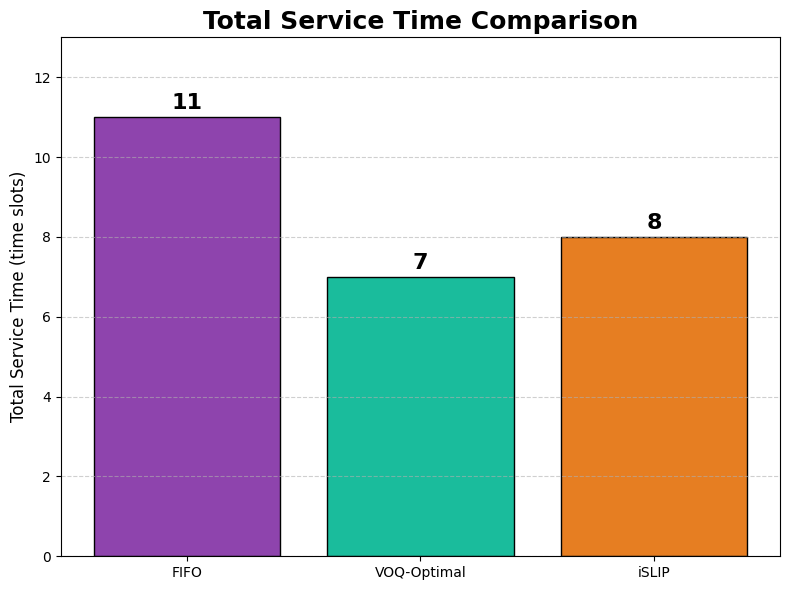

In [9]:
import matplotlib.pyplot as plt

methods = ['FIFO', 'VOQ-Optimal', 'iSLIP']
times = [11, 7, 8]

plt.figure(figsize=(8,6))

# New colors
colors = ['#8e44ad', '#1abc9c', '#e67e22']

bars = plt.bar(methods, times, color=colors, edgecolor='black')

for i, v in enumerate(times):
    plt.text(i, v + 0.2, str(v),
             ha='center', fontsize=16, fontweight='bold')

plt.title("Total Service Time Comparison", fontsize=18, fontweight='bold')
plt.ylabel("Total Service Time (time slots)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 13)

plt.tight_layout()
plt.show()

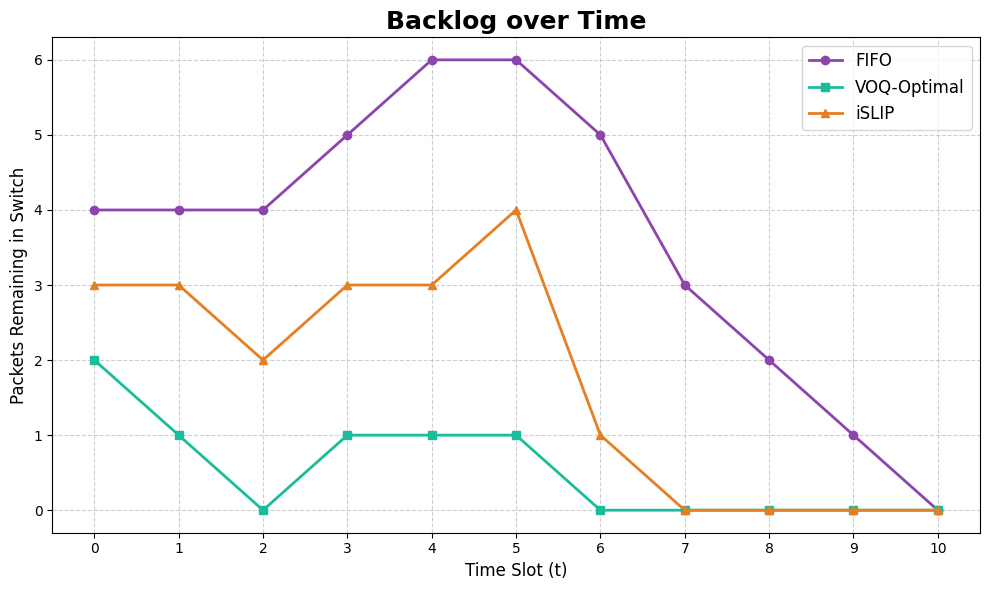

In [10]:
import matplotlib.pyplot as plt

t = list(range(11))

fifo =  [4,4,4,5,6,6,5,3,2,1,0]
voq =   [2,1,0,1,1,1,0,0,0,0,0]
islip = [3,3,2,3,3,4,1,0,0,0,0]

plt.figure(figsize=(10,6))

# New color scheme
plt.plot(t, fifo, marker='o', linewidth=2, label='FIFO', color='#8e44ad')
plt.plot(t, voq, marker='s', linewidth=2, label='VOQ-Optimal', color='#1abc9c')
plt.plot(t, islip, marker='^', linewidth=2, label='iSLIP', color='#e67e22')

plt.title("Backlog over Time", fontsize=18, fontweight='bold')
plt.xlabel("Time Slot (t)", fontsize=12)
plt.ylabel("Packets Remaining in Switch", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.xticks(range(0,11))

plt.tight_layout()
plt.show()